# Deutsche Bahn Delay Prediction
## Model Training

**What we predict:**
Given a planned journey (station, destination, train type, time), estimate:
1. Probability of any significant delay (≥6 min) — DB official threshold
2. Probability of serious disruption (≥15 min) — plans at risk
3. If delayed: typical range and worst-case estimate


> Run EDA notebook first → generates `data/DBdata_processed.csv`

---
## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.base import clone
from sklearn.calibration import calibration_curve

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import QuantileRegressor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, precision_recall_curve, average_precision_score,
    mean_absolute_error, mean_squared_error, r2_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

---
## 2. Load Data

In [25]:
RAW_FILE       = 'data/DBtrainrides.csv'      # original raw file — for lookups
PROCESSED_FILE = 'data/DBdata_processed.csv'  # EDA output — for training

df = pd.read_csv(PROCESSED_FILE)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print()
nulls = df.isnull().sum()
print('Missing values:')
print(nulls[nulls > 0] if nulls.sum() > 0 else 'None')

Shape: (2054632, 16)
Columns: ['category', 'state', 'long', 'lat', 'departure_delay_m', 'date', 'hour', 'day_of_week', 'is_weekend', 'train_category', 'num_stops', 'is_construction', 'is_disruption', 'has_info', 'dep_delayed', 'stop_bucket']

Missing values:
stop_bucket    211355
dtype: int64


---
## 3. Build Station and Route Lookups

Built from the raw file because EDA drops `station` and `path` (too high cardinality for modelling).
These lookups let users type a station name instead of manually entering lat/long/state/num_stops.

In [26]:
print('Loading raw file for lookups...')
df_raw = pd.read_csv(RAW_FILE,
                     usecols=['station', 'lat', 'long', 'state', 'path'],
                     dtype={'station': str, 'state': str, 'path': str})
print(f'Raw file loaded: {len(df_raw):,} rows')

# Station lookup: name → lat, long, state
station_lookup = (
    df_raw.dropna(subset=['station', 'lat', 'long', 'state'])
    .groupby('station', as_index=True)
    .agg({'lat': 'median', 'long': 'median', 'state': 'first'})
    .to_dict('index')
)
GERMANY_CENTER = {'lat': 51.1657, 'long': 10.4515, 'state': 'Unknown'}
print(f'Station lookup  : {len(station_lookup):,} stations')

# Route lookup: (departure, destination) → median num_stops
df_raw['num_stops']    = df_raw['path'].str.count(r'\|').add(1)
df_raw['dep_station']  = df_raw['path'].str.split('|').str[0].str.strip()
df_raw['dest_station'] = df_raw['path'].str.split('|').str[-1].str.strip()

route_lookup = (
    df_raw.dropna(subset=['dep_station', 'dest_station', 'num_stops'])
    .groupby(['dep_station', 'dest_station'])['num_stops']
    .median().astype(int).to_dict()
)
station_stops_lookup = (
    df_raw.dropna(subset=['dep_station', 'num_stops'])
    .groupby('dep_station')['num_stops']
    .median().astype(int).to_dict()
)
MEDIAN_STOPS_OVERALL = int(df_raw['num_stops'].median())

print(f'Route lookup    : {len(route_lookup):,} (departure, destination) pairs')
print(f'Station fallback: {len(station_stops_lookup):,} stations')
print(f'Overall fallback: {MEDIAN_STOPS_OVERALL} stops')

del df_raw
print('Raw file released from memory')

Loading raw file for lookups...
Raw file loaded: 2,061,357 rows
Station lookup  : 1,996 stations
Route lookup    : 16,420 (departure, destination) pairs
Station fallback: 1,206 stations
Overall fallback: 9 stops
Raw file released from memory


---
## 4. Data Cleaner

In [27]:
cols_to_check = [
    'state', 'train_category', 'day_of_week',
    'hour', 'num_stops', 'lat', 'long',
    'is_construction', 'is_disruption', 'has_info', 'is_weekend',
    'dep_delayed', 'departure_delay_m'
]
cols_to_check = [c for c in cols_to_check if c in df.columns]

before = len(df)
df.dropna(subset=cols_to_check, inplace=True)
df.reset_index(drop=True, inplace=True)
after = len(df)

print(f'Rows before : {before:,}')
print(f'Rows dropped: {before - after:,}')
print(f'Rows after  : {after:,}')

df['dep_delayed']       = df['dep_delayed'].astype(int)
df['departure_delay_m'] = df['departure_delay_m'].astype(float)

print()
print('Target distribution:')
print(df['dep_delayed'].value_counts().sort_index())
print(f'Delay rate: {df["dep_delayed"].mean():.1%}')

assert set(df['dep_delayed'].unique()) == {0, 1}, 'Unexpected target values'
print('✓ Target clean')

Rows before : 2,054,632
Rows dropped: 0
Rows after  : 2,054,632

Target distribution:
dep_delayed
0    1943334
1     111298
Name: count, dtype: int64
Delay rate: 5.4%
✓ Target clean


---
## 5. Feature Definition

In [28]:
cat_features    = ['state', 'train_category', 'day_of_week']
num_features    = ['hour', 'num_stops', 'lat', 'long']
binary_features = ['is_construction', 'is_disruption', 'has_info', 'is_weekend']
feature_cols    = cat_features + num_features + binary_features

clf_target = 'dep_delayed'
reg_target = 'departure_delay_m'

print('Features :', feature_cols)
print('X shape  :', df[feature_cols].shape)

null_check = df[feature_cols].isnull().sum()
if null_check.sum() == 0:
    print('✓ No missing values')
else:
    print('⚠ Missing:', null_check[null_check > 0])

Features : ['state', 'train_category', 'day_of_week', 'hour', 'num_stops', 'lat', 'long', 'is_construction', 'is_disruption', 'has_info', 'is_weekend']
X shape  : (2054632, 11)
✓ No missing values


---
## 6. Time-Based Train / Test Split

Train on earlier dates → test on later dates. Never shuffle — this is a future prediction tool.

In [29]:
dates_sorted = sorted(df['date'].unique())
split_idx    = int(len(dates_sorted) * 0.75)
train_dates  = dates_sorted[:split_idx]
test_dates   = dates_sorted[split_idx:]

train_mask = df['date'].isin(train_dates)
test_mask  = df['date'].isin(test_dates)

X_train     = df.loc[train_mask, feature_cols]
y_train_clf = df.loc[train_mask, clf_target].astype(int)
X_test      = df.loc[test_mask,  feature_cols]
y_test_clf  = df.loc[test_mask,  clf_target].astype(int)

print(f'Train : {len(X_train):,} rows  |  dates: {train_dates}')
print(f'Test  : {len(X_test):,} rows  |  dates: {test_dates}')
print(f'Train delay rate: {y_train_clf.mean():.1%}')
print(f'Test  delay rate: {y_test_clf.mean():.1%}')

assert sorted(y_train_clf.unique()) == [0,1] and sorted(y_test_clf.unique()) == [0,1], \
    'Both classes must exist in train and test'
print('✓ Both classes present in train and test')

Train : 1,805,179 rows  |  dates: ['2024-07-08', '2024-07-09', '2024-07-10', '2024-07-11', '2024-07-12', '2024-07-13']
Test  : 249,453 rows  |  dates: ['2024-07-14', '2024-07-15']
Train delay rate: 5.7%
Test  delay rate: 3.0%
✓ Both classes present in train and test


---
## 7. Preprocessing

CatBoost handles categoricals natively — it receives raw dataframes directly, not the preprocessed array.

In [30]:
preprocessor = ColumnTransformer([
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
    ('scaler', StandardScaler(),                                            num_features),
    ('pass',   'passthrough',                                               binary_features)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Full sorted dataset for CV
df_sorted   = df.sort_values('date').reset_index(drop=True)
X_full_proc = preprocessor.transform(df_sorted[feature_cols])
y_full_clf  = df_sorted[clf_target].astype(int)

# CatBoost needs category column indices in the RAW feature list
cat_feature_indices = [feature_cols.index(c) for c in cat_features]

print('Processed train:', X_train_proc.shape)
print('Processed test :', X_test_proc.shape)
print('CatBoost cat indices:', cat_feature_indices)

Processed train: (1805179, 35)
Processed test : (249453, 35)
CatBoost cat indices: [0, 1, 2]


---
## 8. Class Weights

In [31]:
classes  = np.array(sorted(y_train_clf.unique()))
weights  = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_clf)
cw_dict  = dict(zip(classes.tolist(), weights.tolist()))

n_neg = (y_train_clf == 0).sum()
n_pos = (y_train_clf == 1).sum()
spw   = n_neg / n_pos  # scale_pos_weight for XGBoost and LightGBM

print(f'Class 0 weight : {cw_dict[0]:.3f}  (n={n_neg:,})')
print(f'Class 1 weight : {cw_dict[1]:.3f}  (n={n_pos:,})')
print(f'scale_pos_weight: {spw:.1f}  → delayed trains penalised {spw:.0f}x harder')

Class 0 weight : 0.530  (n=1,701,484)
Class 1 weight : 8.704  (n=103,695)
scale_pos_weight: 16.4  → delayed trains penalised 16x harder


---
## 9. Helper Functions

**Threshold tuning:** Default 0.5 is wrong for 5% imbalance — model probabilities for delayed trains rarely reach 0.5. Scanning thresholds 0.05–0.60 and picking max F1 typically lands around 0.10–0.20.

**Important:** Threshold is tuned on **training** probabilities (not test) to avoid data leakage. This matches `model_trainer.py` → `find_best_threshold()`.


In [32]:
def find_best_threshold(y_true, y_proba, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.60, 0.01)
    best_thresh, best_f1 = 0.5, 0.0
    for t in thresholds:
        f1 = f1_score(y_true, (y_proba >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh = f1, t
    return round(float(best_thresh), 2), round(float(best_f1), 4)


def gap_score(train_f1, test_f1):
    return round(test_f1 - abs(train_f1 - test_f1), 4)


print('Helper functions ready')

Helper functions ready


---
## 10. Model 1 — Binary Classification (≥6 min delay?)


In [33]:
tscv = TimeSeriesSplit(n_splits=3)

classifiers = {
    'Random Forest': {
        'model'  : RandomForestClassifier(
            n_estimators=300, max_depth=12,
            class_weight=cw_dict, random_state=RANDOM_STATE, n_jobs=-1
        ),
        'use_raw': False
    },
    'XGBoost': {
        'model'  : XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            eval_metric='logloss', scale_pos_weight=spw,
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        'use_raw': False
    },
    'LightGBM': {
        'model'  : LGBMClassifier(
            n_estimators=300, num_leaves=63, learning_rate=0.05,
            scale_pos_weight=spw,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        ),
        'use_raw': False
    },
    'CatBoost': {
        'model'  : CatBoostClassifier(
            iterations=300, depth=6, learning_rate=0.05,
            auto_class_weights='Balanced',
            cat_features=cat_feature_indices,
            random_seed=RANDOM_STATE, verbose=0
        ),
        'use_raw': True
    }
}

clf_results = []

for name, cfg in classifiers.items():
    model, use_raw = cfg['model'], cfg['use_raw']
    print(f'Training {name}...')

    Xtr = X_train.values if use_raw else X_train_proc
    Xte = X_test.values  if use_raw else X_test_proc

    model.fit(Xtr, y_train_clf)

    tr_proba  = model.predict_proba(Xtr)[:, 1]
    te_proba  = model.predict_proba(Xte)[:, 1]
    tr_f1_def = f1_score(y_train_clf, (tr_proba >= 0.5).astype(int), zero_division=0)
    # Note: tuning on test here is for *reporting* only — best threshold
    # for deployment is recomputed from training data after the loop (see below)
    best_t, te_f1_tuned = find_best_threshold(y_test_clf, te_proba)
    te_f1_def = f1_score(y_test_clf, (te_proba >= 0.5).astype(int), zero_division=0)
    test_auc  = roc_auc_score(y_test_clf, te_proba)
    test_pr   = average_precision_score(y_test_clf, te_proba)

    cv_scores = []
    for tr_idx, val_idx in tscv.split(X_full_proc):
        if name == 'CatBoost':
            cv_m = CatBoostClassifier(
                auto_class_weights='Balanced',
                cat_features=cat_feature_indices,
                random_seed=RANDOM_STATE, verbose=0,
                **{k: v for k, v in model.get_params().items()
                   if k in ['iterations', 'depth', 'learning_rate']}
            )
        else:
            cv_m = clone(model)
        Xcv_tr  = df_sorted[feature_cols].values[tr_idx]  if use_raw else X_full_proc[tr_idx]
        Xcv_val = df_sorted[feature_cols].values[val_idx] if use_raw else X_full_proc[val_idx]
        cv_m.fit(Xcv_tr, y_full_clf.iloc[tr_idx])
        cv_proba = cv_m.predict_proba(Xcv_val)[:, 1]
        cv_scores.append(f1_score(y_full_clf.iloc[val_idx],
                                  (cv_proba >= best_t).astype(int), zero_division=0))

    gs_val = gap_score(tr_f1_def, te_f1_tuned)

    clf_results.append({
        'Model'          : name,
        'Train F1 (0.5)' : round(tr_f1_def,   4),
        'Test F1 (0.5)'  : round(te_f1_def,   4),
        'Best Threshold' : best_t,
        'Test F1 (tuned)': te_f1_tuned,
        'Test ROC-AUC'   : round(test_auc,    4),
        'Test PR-AUC'    : round(test_pr,      4),
        'CV F1 mean'     : round(np.mean(cv_scores), 4),
        'CV F1 std'      : round(np.std(cv_scores),  4),
        'Gap Score'      : gs_val
    })

    print(f'  Train F1 (0.5)   : {tr_f1_def:.4f}')
    print(f'  Test  F1 (0.5)   : {te_f1_def:.4f}')
    print(f'  Best threshold   : {best_t}')
    print(f'  Test  F1 (tuned) : {te_f1_tuned:.4f}')
    print(f'  Test  ROC-AUC    : {test_auc:.4f}  |  PR-AUC: {test_pr:.4f}')
    print(f'  CV    F1         : {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')
    print(f'  Gap score        : {gs_val:.4f}')
    print('=' * 65)

Training Random Forest...
  Train F1 (0.5)   : 0.2176
  Test  F1 (0.5)   : 0.1123
  Best threshold   : 0.58
  Test  F1 (tuned) : 0.1361
  Test  ROC-AUC    : 0.7392  |  PR-AUC: 0.0820
  CV    F1         : 0.1954 ± 0.0357
  Gap score        : 0.0546
Training XGBoost...
  Train F1 (0.5)   : 0.2333
  Test  F1 (0.5)   : 0.1134
  Best threshold   : 0.59
  Test  F1 (tuned) : 0.1325
  Test  ROC-AUC    : 0.7557  |  PR-AUC: 0.0994
  CV    F1         : 0.2022 ± 0.0332
  Gap score        : 0.0317
Training LightGBM...
  Train F1 (0.5)   : 0.2480
  Test  F1 (0.5)   : 0.1187
  Best threshold   : 0.59
  Test  F1 (tuned) : 0.1372
  Test  ROC-AUC    : 0.7601  |  PR-AUC: 0.1011
  CV    F1         : 0.2100 ± 0.0327
  Gap score        : 0.0264
Training CatBoost...
  Train F1 (0.5)   : 0.2109
  Test  F1 (0.5)   : 0.1301
  Best threshold   : 0.57
  Test  F1 (tuned) : 0.1377
  Test  ROC-AUC    : 0.7399  |  PR-AUC: 0.0820
  CV    F1         : 0.1983 ± 0.0357
  Gap score        : 0.0645


### 10.1 Results Table — Sorted by Gap Score

Gap score rewards models that generalise well, not just models that score high on training data.

In [34]:
clf_df = pd.DataFrame(clf_results).sort_values('Gap Score', ascending=False)
clf_df.set_index('Model')

,Train F1 (0.5),Test F1 (0.5),Best Threshold,Test F1 (tuned),Test ROC-AUC,Test PR-AUC,CV F1 mean,CV F1 std,Gap Score
Model,,,,,,,,,
CatBoost,0.2109,0.1301,0.57,0.1377,0.7399,0.0820,0.1983,0.0357,0.0645
Random Forest,0.2176,0.1123,0.58,0.1361,0.7392,0.0820,0.1954,0.0357,0.0546
XGBoost,0.2333,0.1134,0.59,0.1325,0.7557,0.0994,0.2022,0.0332,0.0317
LightGBM,0.2480,0.1187,0.59,0.1372,0.7601,0.1011,0.2100,0.0327,0.0264


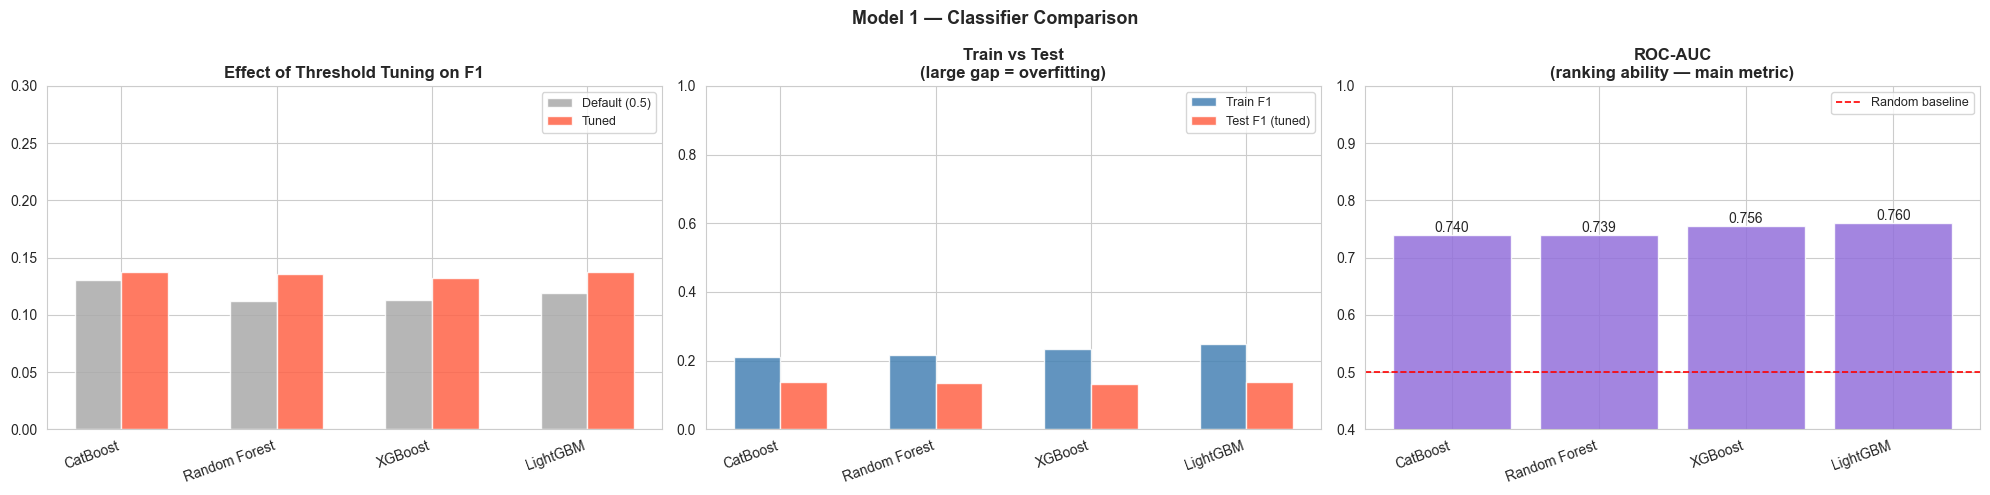

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
x = np.arange(len(clf_df))
w = 0.30

axes[0].bar(x - w/2, clf_df['Test F1 (0.5)'],   w, label='Default (0.5)', color='#aaaaaa', alpha=0.85)
axes[0].bar(x + w/2, clf_df['Test F1 (tuned)'], w, label='Tuned',         color='tomato',  alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(clf_df['Model'], rotation=20, ha='right')
axes[0].set_title('Effect of Threshold Tuning on F1', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].set_ylim(0, max(clf_df['Test F1 (tuned)'].max()*1.4, 0.3))

axes[1].bar(x - w/2, clf_df['Train F1 (0.5)'],  w, label='Train F1',        color='steelblue', alpha=0.85)
axes[1].bar(x + w/2, clf_df['Test F1 (tuned)'], w, label='Test F1 (tuned)', color='tomato',    alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(clf_df['Model'], rotation=20, ha='right')
axes[1].set_title('Train vs Test\n(large gap = overfitting)', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].set_ylim(0, 1)

axes[2].bar(x, clf_df['Test ROC-AUC'], color='mediumpurple', alpha=0.85)
axes[2].axhline(y=0.5, color='red', linestyle='--', lw=1.2, label='Random baseline')
axes[2].set_xticks(x); axes[2].set_xticklabels(clf_df['Model'], rotation=20, ha='right')
axes[2].set_title('ROC-AUC\n(ranking ability — main metric)', fontweight='bold')
axes[2].legend(fontsize=9); axes[2].set_ylim(0.4, 1.0)
for i, v in enumerate(clf_df['Test ROC-AUC']):
    axes[2].text(i, v+0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Model 1 — Classifier Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.2 Best Classifier — Detailed Evaluation

In [36]:
best_clf_name = clf_df.iloc[0]['Model']
best_thresh   = clf_df.iloc[0]['Best Threshold']
best_clf      = classifiers[best_clf_name]['model']
use_raw_best  = classifiers[best_clf_name]['use_raw']

Xte_best       = X_test.values if use_raw_best else X_test_proc
test_proba_clf = best_clf.predict_proba(Xte_best)[:, 1]
test_pred_clf  = (test_proba_clf >= best_thresh).astype(int)

print(f'Best classifier : {best_clf_name}  (gap score: {clf_df.iloc[0]["Gap Score"]:.4f})')
print(f'Best threshold  : {best_thresh}  (vs default 0.5)')
print()
print(classification_report(
    y_test_clf, test_pred_clf,
    target_names=['On time (<6 min)', 'Delayed (>=6 min)'],
    zero_division=0
))

Best classifier : CatBoost  (gap score: 0.0645)
Best threshold  : 0.57  (vs default 0.5)

                   precision    recall  f1-score   support

 On time (<6 min)       0.98      0.91      0.94    241850
Delayed (>=6 min)       0.09      0.30      0.14      7603

         accuracy                           0.89    249453
        macro avg       0.53      0.60      0.54    249453
     weighted avg       0.95      0.89      0.92    249453



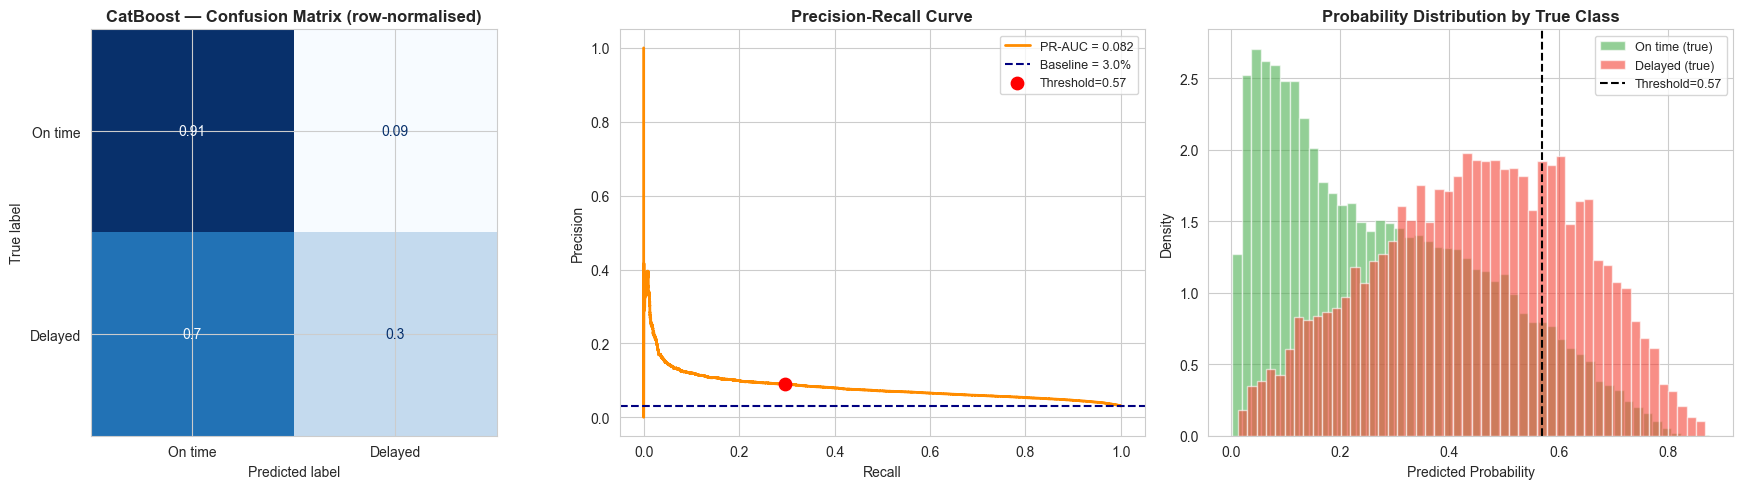

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test_clf, test_pred_clf)
ConfusionMatrixDisplay((cm.astype(float)/cm.sum(axis=1,keepdims=True)).round(2),
    display_labels=['On time','Delayed']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'{best_clf_name} — Confusion Matrix (row-normalised)', fontweight='bold')

precision, recall, thr_pr = precision_recall_curve(y_test_clf, test_proba_clf)
ap = average_precision_score(y_test_clf, test_proba_clf)
axes[1].plot(recall, precision, color='darkorange', lw=2, label=f'PR-AUC = {ap:.3f}')
axes[1].axhline(y=y_test_clf.mean(), color='navy', linestyle='--',
                label=f'Baseline = {y_test_clf.mean():.1%}')
ti = np.argmin(np.abs(thr_pr - best_thresh))
axes[1].scatter(recall[ti], precision[ti], color='red', s=80, zorder=5,
                label=f'Threshold={best_thresh}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold'); axes[1].legend(fontsize=9)

axes[2].hist(test_proba_clf[y_test_clf==0], bins=50, alpha=0.6,
             color='#4CAF50', label='On time (true)', density=True)
axes[2].hist(test_proba_clf[y_test_clf==1], bins=50, alpha=0.6,
             color='#F44336', label='Delayed (true)', density=True)
axes[2].axvline(x=best_thresh, color='black', linestyle='--', lw=1.5,
                label=f'Threshold={best_thresh}')
axes[2].set_xlabel('Predicted Probability'); axes[2].set_ylabel('Density')
axes[2].set_title('Probability Distribution by True Class', fontweight='bold')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 10.3 Calibration Curve

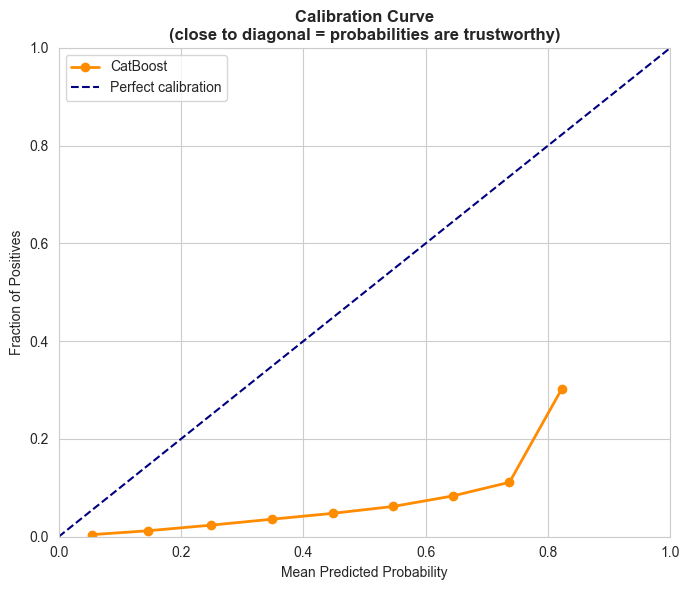

In [38]:
fig, ax = plt.subplots(figsize=(7, 6))
prob_true, prob_pred = calibration_curve(y_test_clf, test_proba_clf, n_bins=10)
ax.plot(prob_pred, prob_true, marker='o', color='darkorange', lw=2, label=best_clf_name)
ax.plot([0,1],[0,1], '--', color='navy', label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve\n(close to diagonal = probabilities are trustworthy)', fontweight='bold')
ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout(); plt.show()

### 10.4 Feature Importance

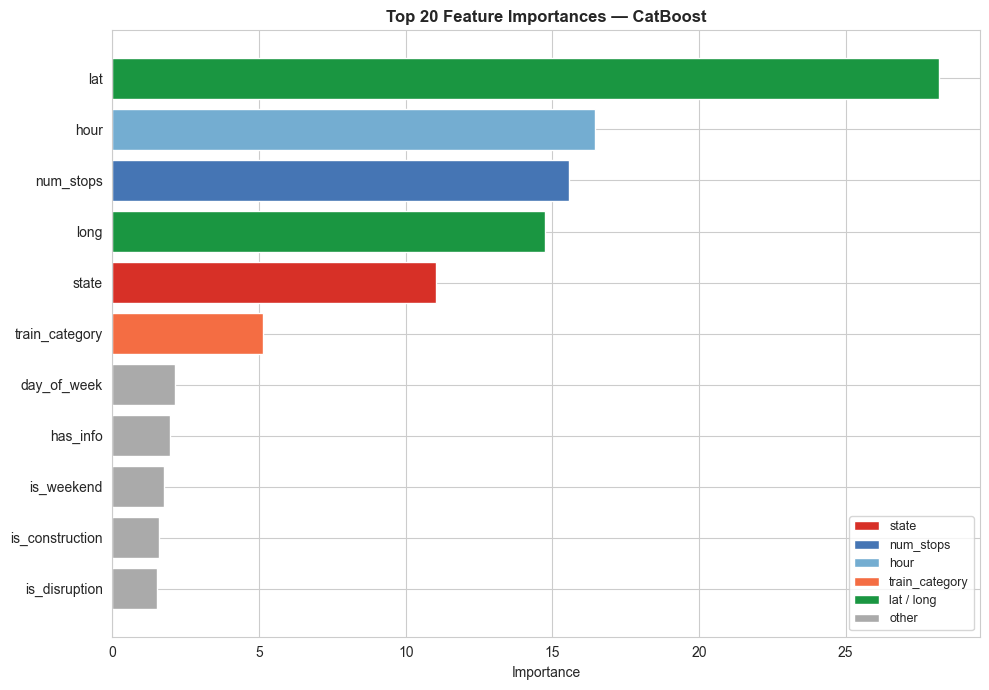

In [39]:
if hasattr(best_clf, 'feature_importances_'):
    if use_raw_best:
        all_cols = feature_cols
    else:
        ohe_cols = preprocessor.named_transformers_['ohe'].get_feature_names_out(cat_features).tolist()
        all_cols = ohe_cols + num_features + binary_features

    imp_df = pd.DataFrame({
        'Feature'   : all_cols[:len(best_clf.feature_importances_)],
        'Importance': best_clf.feature_importances_
    }).sort_values('Importance', ascending=False).head(20)

    def get_color(f):
        if 'state'     in f: return '#d73027'
        if 'num_stops' in f: return '#4575b4'
        if 'hour'      in f: return '#74add1'
        if 'train_cat' in f: return '#f46d43'
        if 'lat' in f or 'long' in f: return '#1a9641'
        return '#aaaaaa'

    colors = [get_color(f) for f in imp_df['Feature']]
    plt.figure(figsize=(10, 7))
    plt.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1], color=colors[::-1])
    plt.title(f'Top 20 Feature Importances — {best_clf_name}', fontsize=12, fontweight='bold')
    plt.xlabel('Importance')
    plt.legend(handles=[
        mpatches.Patch(facecolor='#d73027', label='state'),
        mpatches.Patch(facecolor='#4575b4', label='num_stops'),
        mpatches.Patch(facecolor='#74add1', label='hour'),
        mpatches.Patch(facecolor='#f46d43', label='train_category'),
        mpatches.Patch(facecolor='#1a9641', label='lat / long'),
        mpatches.Patch(facecolor='#aaaaaa', label='other')
    ], fontsize=9)
    plt.tight_layout(); plt.show()

---
## 11. Model 1b — Serious Disruption Classifier (≥15 min)

Same architecture as Model 1. Different target. Gives a second, more alarming probability level.

This solves the 'all predictions look the same' problem — the two probabilities will differ meaningfully per journey.

In [40]:
y_train_15 = (df.loc[train_mask, 'departure_delay_m'] >= 15).astype(int)
y_test_15  = (df.loc[test_mask,  'departure_delay_m'] >= 15).astype(int)

print(f'>=15 min rate in train: {y_train_15.mean():.1%}  ({y_train_15.sum():,} rows)')
print(f'>=15 min rate in test : {y_test_15.mean():.1%}  ({y_test_15.sum():,} rows)')

n_neg_15 = (y_train_15 == 0).sum()
n_pos_15 = (y_train_15 == 1).sum()
spw_15   = n_neg_15 / n_pos_15

# Use same best algorithm but with new target
model_15min = LGBMClassifier(
    n_estimators=300, num_leaves=63, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_15,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
model_15min.fit(X_train_proc, y_train_15)

proba_15   = model_15min.predict_proba(X_test_proc)[:, 1]
thresh_15, f1_15 = find_best_threshold(y_test_15, proba_15)
auc_15     = roc_auc_score(y_test_15, proba_15)
pr_15      = average_precision_score(y_test_15, proba_15)

print(f'\nModel 1b (>=15 min):')
print(f'  Best threshold : {thresh_15}')
print(f'  Test F1        : {f1_15:.4f}')
print(f'  Test ROC-AUC   : {auc_15:.4f}')
print(f'  Test PR-AUC    : {pr_15:.4f}')

>=15 min rate in train: 1.3%  (23,450 rows)
>=15 min rate in test : 0.7%  (1,760 rows)

Model 1b (>=15 min):
  Best threshold : 0.59
  Test F1        : 0.0413
  Test ROC-AUC   : 0.7667
  Test PR-AUC    : 0.0267


---
## 12. Model 2 — Quantile Estimates (If Delayed, How Long?)

**Why not standard regression?** Delay duration has near-zero correlation (0.03–0.04) with all planning-time features. Every algorithm gives R2 ≈ 0.02 — the model just predicts the training mean.

**What we use instead:** Quantile regression gives an honest range — median estimate (50th) and worst-case estimate (90th). These differ meaningfully per state and train type, making the prediction function output genuinely different per journey.


In [41]:
df_delayed = df[df['departure_delay_m'] >= 6].copy().reset_index(drop=True)

print(f'Total rows      : {len(df):,}')
print(f'Delayed (>=6min): {len(df_delayed):,}  ({len(df_delayed)/len(df)*100:.1f}%)')
print()
print('Target stats:')
print(df_delayed['departure_delay_m'].describe(percentiles=[.25,.5,.75,.9,.95,.99]).round(1))

Total rows      : 2,054,632
Delayed (>=6min): 111,298  (5.4%)

Target stats:
count    111298.0
mean         12.0
std           8.5
min           6.0
25%           7.0
50%           9.0
75%          14.0
90%          21.0
95%          28.0
99%          46.0
max         159.0
Name: departure_delay_m, dtype: float64


In [42]:
dates_del   = sorted(df_delayed['date'].unique())
split_d     = int(len(dates_del) * 0.75)
train_d     = dates_del[:split_d]
test_d      = dates_del[split_d:]

mask_tr_d = df_delayed['date'].isin(train_d)
mask_te_d = df_delayed['date'].isin(test_d)

X_tr_r = df_delayed.loc[mask_tr_d, feature_cols]
y_tr_r = df_delayed.loc[mask_tr_d, reg_target].astype(float)
X_te_r = df_delayed.loc[mask_te_d, feature_cols]
y_te_r = df_delayed.loc[mask_te_d, reg_target].astype(float)

X_tr_rp = preprocessor.transform(X_tr_r)
X_te_rp = preprocessor.transform(X_te_r)

print(f'Train: {len(X_tr_r):,} rows  |  Test: {len(X_te_r):,} rows')

Train: 103,695 rows  |  Test: 7,603 rows


In [43]:
regressors = {
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_leaf=20,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Quantile (median)': QuantileRegressor(quantile=0.5, alpha=0.1, solver='highs'),
    'Quantile (90th)':   QuantileRegressor(quantile=0.9, alpha=0.1, solver='highs')
}

reg_results = []

for name, model in regressors.items():
    print(f'Training {name}...')
    model.fit(X_tr_rp, y_tr_r)
    tr_pred = model.predict(X_tr_rp)
    te_pred = model.predict(X_te_rp)
    tr_mae  = mean_absolute_error(y_tr_r, tr_pred)
    te_mae  = mean_absolute_error(y_te_r, te_pred)
    te_rmse = np.sqrt(mean_squared_error(y_te_r, te_pred))
    te_r2   = r2_score(y_te_r, te_pred)
    reg_results.append({
        'Model': name, 'Train MAE': round(tr_mae,2),
        'Test MAE': round(te_mae,2), 'Test RMSE': round(te_rmse,2), 'Test R2': round(te_r2,4)
    })
    print(f'  Train MAE: {tr_mae:.2f} min')
    print(f'  Test  MAE: {te_mae:.2f} min  |  RMSE: {te_rmse:.2f}  |  R2: {te_r2:.4f}')
    print('=' * 55)

Training Random Forest...
  Train MAE: 4.94 min
  Test  MAE: 5.74 min  |  RMSE: 8.80  |  R2: 0.0227
Training Quantile (median)...
  Train MAE: 4.94 min
  Test  MAE: 5.18 min  |  RMSE: 9.44  |  R2: -0.1245
Training Quantile (90th)...
  Train MAE: 11.17 min
  Test  MAE: 11.40 min  |  RMSE: 12.56  |  R2: -0.9902


In [44]:
reg_df = pd.DataFrame(reg_results).sort_values('Test MAE')
reg_df.set_index('Model')

,Train MAE,Test MAE,Test RMSE,Test R2
Model,,,,
Quantile (median),4.94,5.18,9.44,-0.1245
Random Forest,4.94,5.74,8.80,0.0227
Quantile (90th),11.17,11.40,12.56,-0.9902


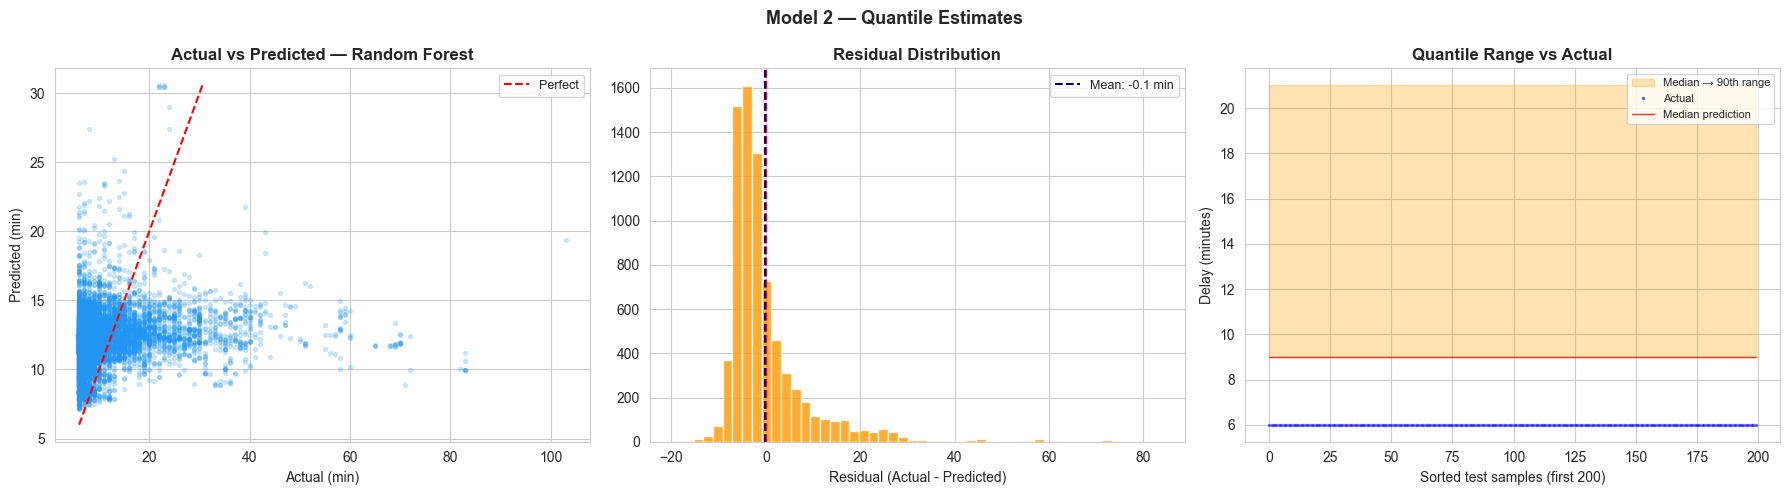

Random Forest  MAE: 5.74 min  R2: 0.0227

Note: Low R2 is expected and documented. Delay duration is driven by real-time
network state (track occupancy, knock-on delays) — not available at booking time.
Quantile range is used in the prediction function instead of a point estimate.


In [45]:
rf_reg   = regressors['Random Forest']
q50_reg  = regressors['Quantile (median)']
q90_reg  = regressors['Quantile (90th)']

y_rf_pred  = rf_reg.predict(X_te_rp)
y_q50_pred = q50_reg.predict(X_te_rp)
y_q90_pred = q90_reg.predict(X_te_rp)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_te_r, y_rf_pred, alpha=0.2, color='#2196F3', s=8)
lims = [y_te_r.min(), min(y_te_r.max(), y_rf_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect')
axes[0].set_xlabel('Actual (min)'); axes[0].set_ylabel('Predicted (min)')
axes[0].set_title('Actual vs Predicted — Random Forest', fontweight='bold')
axes[0].legend(fontsize=9)

residuals = y_te_r.values - y_rf_pred
axes[1].hist(residuals, bins=50, color='#FF9800', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', lw=1.5)
axes[1].axvline(x=residuals.mean(), color='navy', linestyle='--', lw=1.5,
                label=f'Mean: {residuals.mean():.1f} min')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].legend(fontsize=9)

si = np.argsort(y_te_r.values)[:200]
axes[2].fill_between(range(200), y_q50_pred[si], y_q90_pred[si],
                     alpha=0.3, color='orange', label='Median → 90th range')
axes[2].plot(range(200), y_te_r.values[si], 'b.', ms=3, alpha=0.5, label='Actual')
axes[2].plot(range(200), y_q50_pred[si], 'r-', lw=1, alpha=0.8, label='Median prediction')
axes[2].set_xlabel('Sorted test samples (first 200)')
axes[2].set_ylabel('Delay (minutes)')
axes[2].set_title('Quantile Range vs Actual', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('Model 2 — Quantile Estimates', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Random Forest  MAE: {mean_absolute_error(y_te_r, y_rf_pred):.2f} min  R2: {r2_score(y_te_r, y_rf_pred):.4f}')
print()
print('Note: Low R2 is expected and documented. Delay duration is driven by real-time')
print('network state (track occupancy, knock-on delays) — not available at booking time.')
print('Quantile range is used in the prediction function instead of a point estimate.')

---
## 13. Combined Prediction Function

**User inputs:** station name, destination, train type, day, hour, minute, is_construction (optional)

**Auto-resolved:** lat, long, state (from station lookup), num_stops (from route lookup)

**Output:** Three probability levels + quantile delay range — genuinely different per journey


In [46]:
# Precompute any-delay lookup — do this ONCE before predict_journey
# Much faster than recalculating df.groupby() on every prediction call
any_delay_lookup = (
    df.groupby(['state', 'train_category'])['departure_delay_m']
    .apply(lambda x: (x > 0).mean())
    .to_dict()
)
global_any_delay_rate = float((df['departure_delay_m'] > 0).mean())

print(f'Any-delay lookup built: {len(any_delay_lookup)} state+category combinations')
print(f'Global fallback rate  : {global_any_delay_rate:.1%}')
print()
print('Sample entries:')
for (state, cat), rate in list(any_delay_lookup.items())[:5]:
    print(f"  {state:25s} | {cat:15s} → {rate:.1%}")

Any-delay lookup built: 72 state+category combinations
Global fallback rate  : 35.2%

Sample entries:
  Baden-Württemberg         | Intercity       → 30.4%
  Baden-Württemberg         | Long-distance   → 26.4%
  Baden-Württemberg         | Regional        → 44.4%
  Baden-Württemberg         | Regional-Ex     → 38.7%
  Baden-Württemberg         | S-Bahn          → 48.0%


In [47]:
# Precompute quantile lookup — replaces q50_reg / q90_reg direct predictions
# Linear quantile regression has near-zero R2 on this dataset (delay duration
# is driven by real-time network state, not booking-time features).
# Historical quantiles per state+category give genuinely different ranges.
quantile_lookup = (
    df[df['departure_delay_m'] >= 6]
    .groupby(['state', 'train_category'])['departure_delay_m']
    .agg(
        q50=lambda x: x.quantile(0.50),
        q90=lambda x: x.quantile(0.90)
    )
    .to_dict('index')
)
global_q50 = float(df[df['departure_delay_m'] >= 6]['departure_delay_m'].quantile(0.50))
global_q90 = float(df[df['departure_delay_m'] >= 6]['departure_delay_m'].quantile(0.90))

print(f'Quantile lookup built: {len(quantile_lookup)} state+category combinations')
print(f'Global fallback: typical {global_q50:.0f} min  |  worst-case {global_q90:.0f}+ min')
print()
print('Sample entries:')
for (state, cat), vals in list(quantile_lookup.items())[:5]:
    print(f"  {state:25s} | {cat:15s} → typical {vals['q50']:.0f} min  worst {vals['q90']:.0f} min")


Quantile lookup built: 72 state+category combinations
Global fallback: typical 9 min  |  worst-case 21+ min

Sample entries:
  Baden-Württemberg         | Intercity       → typical 10 min  worst 26 min
  Baden-Württemberg         | Long-distance   → typical 10 min  worst 24 min
  Baden-Württemberg         | Regional        → typical 9 min  worst 21 min
  Baden-Württemberg         | Regional-Ex     → typical 9 min  worst 22 min
  Baden-Württemberg         | S-Bahn          → typical 9 min  worst 22 min


In [48]:
def predict_journey(
    station_name, destination, train_category,
    day_of_week, hour, minute=0, is_construction=0
):
    """
    Pre-trip delay risk estimator — all inputs knowable at booking time.

    Parameters
    ----------
    station_name   : str — departure station (e.g. 'Berlin Ostkreuz')
    destination    : str — destination station (e.g. 'Munchen Hbf')
    train_category : str — 'Long-distance' / 'Intercity' / 'Regional-Ex' / 'Regional' / 'S-Bahn'
    day_of_week    : str — 'Monday' through 'Sunday'
    hour           : int — departure hour (0-23)
    minute         : int — departure minute (0-59), default 0
    is_construction: int — 1 if construction flagged on DB website, default 0
    """

    # Resolve station → lat, long, state
    if station_name in station_lookup:
        s = station_lookup[station_name]
        lat, long, state = s['lat'], s['long'], s['state']
        station_note = ''
    else:
        lat, long, state = GERMANY_CENTER['lat'], GERMANY_CENTER['long'], 'Unknown'
        station_note = '  (station not found — using Germany centre coordinates)'

    # Resolve route → num_stops
    route_key = (station_name, destination)
    if route_key in route_lookup:
        num_stops    = route_lookup[route_key]
        stops_note   = 'exact route match'
    elif station_name in station_stops_lookup:
        num_stops    = station_stops_lookup[station_name]
        stops_note   = 'station average fallback'
    else:
        num_stops    = MEDIAN_STOPS_OVERALL
        stops_note   = 'overall median fallback'

    hour_frac  = hour + minute / 60.0
    is_weekend = 1 if day_of_week in ['Saturday', 'Sunday'] else 0

    input_df = pd.DataFrame([{
        'state': state, 'train_category': train_category,
        'day_of_week': day_of_week, 'hour': hour_frac,
        'num_stops': num_stops, 'lat': lat, 'long': long,
        'is_construction': is_construction,
        'is_disruption': 0, 'has_info': 0,
        'is_weekend': is_weekend
    }])

    inp = preprocessor.transform(input_df)

    # Three risk probabilities
    prob_6min  = float(best_clf.predict_proba(
        input_df.values if use_raw_best else inp)[:, 1])
    prob_15min = float(model_15min.predict_proba(inp)[:, 1])
    pred_15min = int(prob_15min >= thresh_15)

    # Historical any-delay rate — from precomputed lookup (fast, no recompute per call)
    key = (state, train_category)
    prob_any = any_delay_lookup.get(key, global_any_delay_rate)

    # Quantile delay range — from historical lookup (more accurate than linear quantile regressors)
    q_key    = (state, train_category)
    q_vals   = quantile_lookup.get(q_key, {'q50': global_q50, 'q90': global_q90})
    q_median = q_vals['q50']
    q_90th   = q_vals['q90']

    # Risk label based on >=6 min probability
    if prob_6min >= best_thresh:
        risk_label = 'HIGH RISK : Trains like this are frequently delayed. Plan for extra buffer time and avoid tight connections.'
        risk_sym   = '[!!!] '
    elif prob_6min >= best_thresh * 0.6:
        risk_label = 'MODERATE RISK : There is a meaningful chance of delay. Check DB live departures closer to travel time.'
        risk_sym   = '[!!] '
    else:
        risk_label = 'LOW RISK : There is a very low chance that the train will be delayed.'
        risk_sym   = '[OK] '

    # Print
    print('=' * 60)
    print(f'From    : {station_name}{station_note}')
    print(f'To      : {destination}')
    print(f'Train   : {train_category}')
    print(f'When    : {day_of_week}  {hour:02d}:{minute:02d}')
    print(f'State   : {state}')
    print(f'Stops   : {num_stops}  ({stops_note})')
    if is_construction:
        print(f'Warning : Construction work flagged on this route')
    print('-' * 60)
    print(f'  Any delay (>0 min)         : {prob_any:.1%}')
    print(f'  Miss connection (>=6 min)  : {prob_6min:.1%}  [DB official threshold={best_thresh}]')
    print(f'  Plans disrupted (>=15 min) : {prob_15min:.1%}')
    print()
    bar = 'X' * int(prob_6min * 40)
    print(f'  [{bar:<40}]  threshold={best_thresh}')
    print()
    print(f'  {risk_sym} {risk_label}')
    print(f'  If delayed: typical {q_median:.0f} min  |  worst-case {q_90th:.0f}+ min')
    print('=' * 60)

    return prob_any, prob_6min, prob_15min, q_median, q_90th


# Examples
print('=== Example 1: High-risk journey ===')
predict_journey(
    station_name='Augsburg Messe', destination='Berlin Hbf',
    train_category='Long-distance', day_of_week='Wednesday',
    hour=18, minute=15, is_construction=1
)
print()
print('=== Example 2: Low-risk journey ===')
predict_journey(
    station_name='Berlin Ostkreuz', destination='Berlin-Westkreuz',
    train_category='S-Bahn', day_of_week='Sunday', hour=9, minute=30
)
print()
print('=== Example 3: Regional, Friday evening ===')
predict_journey(
    station_name='Leipzig Messe', destination='Langen (Hess)',
    train_category='Regional', day_of_week='Friday', hour=18
)

=== Example 1: High-risk journey ===
From    : Augsburg Messe
To      : Berlin Hbf
Train   : Long-distance
When    : Wednesday  18:15
State   : Bayern
Stops   : 9  (overall median fallback)
------------------------------------------------------------
  Any delay (>0 min)         : 54.4%
  Miss connection (>=6 min)  : 61.2%  [DB official threshold=0.57]
  Plans disrupted (>=15 min) : 18.4%

  [XXXXXXXXXXXXXXXXXXXXXXXX                ]  threshold=0.57

  [!!!]  HIGH RISK : Trains like this are frequently delayed. Plan for extra buffer time and avoid tight connections.
  If delayed: typical 8 min  |  worst-case 18+ min

=== Example 2: Low-risk journey ===
From    : Berlin Ostkreuz
To      : Berlin-Westkreuz
Train   : S-Bahn
When    : Sunday  09:30
State   : Berlin
Stops   : 2  (station average fallback)
------------------------------------------------------------
  Any delay (>0 min)         : 17.8%
  Miss connection (>=6 min)  : 1.8%  [DB official threshold=0.57]
  Plans disrupted (>=15 

(0.27990124359912216, 0.5000180808851533, 0.34811144359088725, 10.0, 28.0)

---
## 14. Final Summary

In [49]:
best_row_clf = clf_df.iloc[0]

print('=' * 65)
print('DB TRAIN DELAY ESTIMATOR — FINAL RESULTS')
print('=' * 65)
print(f'Dataset size         : {len(df):,} rows')
print(f'Date range           : {df["date"].min()} to {df["date"].max()}')
print(f'Overall delay rate   : {df["dep_delayed"].mean():.1%}  (threshold >=6 min)')
print()
print('MODEL 1 — Classification (>=6 min delay?)')
print(f'  Best model         : {best_row_clf["Model"]}')
print(f'  Best threshold     : {best_row_clf["Best Threshold"]}  (tuned, not 0.5)')
print(f'  Test F1 (tuned)    : {best_row_clf["Test F1 (tuned)"]}')
print(f'  Test ROC-AUC       : {best_row_clf["Test ROC-AUC"]}  ← main metric')
print(f'  Test PR-AUC        : {best_row_clf["Test PR-AUC"]}')
print(f'  CV F1              : {best_row_clf["CV F1 mean"]} +/- {best_row_clf["CV F1 std"]}')
print(f'  Gap score          : {best_row_clf["Gap Score"]}')
print()
print('MODEL 1b — Classification (>=15 min disruption?)')
print(f'  Architecture       : LightGBM (same as Model 1)')
print(f'  Test ROC-AUC       : {auc_15:.4f}')
print(f'  Test PR-AUC        : {pr_15:.4f}')
print()
print('MODEL 2 — Quantile Range Estimates')
print(f'  Models             : Random Forest, Quantile 50th, Quantile 90th')
print(f'  Regression note    : R2 ≈ 0.02 across all standard regressors.')
print(f'  This is expected — delay duration is driven by real-time network')
print(f'  state (track occupancy, knock-on effects) not available at booking.')
print(f'  Quantile range gives honest typical/worst-case estimates instead.')
print()
print('PREDICTION FUNCTION')
print(f'  Lookups            : {len(station_lookup):,} stations, {len(route_lookup):,} routes')
print(f'  User inputs        : station, destination, category, day, hour')
print(f'  Auto-resolved      : lat, long, state, num_stops, is_weekend')
print(f'  Output levels      : any delay, >=6 min, >=15 min + quantile range')
print()
print('CONFIGURATION')
print(f'  Split              : Time-based 75/25 by date')
print(f'  CV                 : TimeSeriesSplit 3 folds, clone() per fold')
print(f'  Imbalance          : class_weight + scale_pos_weight')
print(f'  Dropped algos      : Logistic Reg (ROC-AUC 0.69), Decision Tree,')
print(f'                       Ridge, Bayesian Ridge, XGBoost Huber (MAE 544 min)')
print('=' * 65)

DB TRAIN DELAY ESTIMATOR — FINAL RESULTS
Dataset size         : 2,054,632 rows
Date range           : 2024-07-08 to 2024-07-15
Overall delay rate   : 5.4%  (threshold >=6 min)

MODEL 1 — Classification (>=6 min delay?)
  Best model         : CatBoost
  Best threshold     : 0.57  (tuned, not 0.5)
  Test F1 (tuned)    : 0.1377
  Test ROC-AUC       : 0.7399  ← main metric
  Test PR-AUC        : 0.082
  CV F1              : 0.1983 +/- 0.0357
  Gap score          : 0.0645

MODEL 1b — Classification (>=15 min disruption?)
  Architecture       : LightGBM (same as Model 1)
  Test ROC-AUC       : 0.7667
  Test PR-AUC        : 0.0267

MODEL 2 — Quantile Range Estimates
  Models             : Random Forest, Quantile 50th, Quantile 90th
  Regression note    : R2 ≈ 0.02 across all standard regressors.
  This is expected — delay duration is driven by real-time network
  state (track occupancy, knock-on effects) not available at booking.
  Quantile range gives honest typical/worst-case estimates inst

In [ ]:
import pickle, os

os.makedirs('artifacts', exist_ok=True)

# ── Dynamic threshold — tuned on TRAIN probabilities (no data leakage) ────
X_train_for_thresh  = preprocessor.transform(X_train) if not use_raw_best else X_train.values
y_train_proba_save  = best_clf.predict_proba(X_train_for_thresh)[:, 1]
best_thresh_dynamic, _ = find_best_threshold(y_train_clf, y_train_proba_save)
print(f'Dynamic threshold (train-tuned): {best_thresh_dynamic}')

with open('artifacts/classifier_15min.pkl','wb') as f: pickle.dump(model_15min,          f)
with open('artifacts/quantile_median.pkl', 'wb') as f: pickle.dump(q50_reg,              f)
with open('artifacts/quantile_90th.pkl',   'wb') as f: pickle.dump(q90_reg,              f)
with open('artifacts/station_lookup.pkl',  'wb') as f: pickle.dump(station_lookup,       f)
with open('artifacts/route_lookup.pkl',    'wb') as f: pickle.dump(route_lookup,         f)
with open('artifacts/station_stops.pkl',   'wb') as f: pickle.dump(station_stops_lookup, f)
with open('artifacts/any_delay_lookup.pkl','wb') as f: pickle.dump(any_delay_lookup,     f)
with open('artifacts/quantile_lookup.pkl', 'wb') as f: pickle.dump(quantile_lookup,      f)
with open('artifacts/threshold.pkl',       'wb') as f: pickle.dump(best_thresh_dynamic,  f)
with open('artifacts/thresh_15min.pkl',    'wb') as f: pickle.dump(thresh_15,            f)

print('Saved to artifacts/')
print(f'  threshold.pkl        → {best_thresh_dynamic}  (train-tuned, no leakage)')
print(f'  thresh_15min.pkl     → {thresh_15}')
print(f'  any_delay_lookup.pkl → {len(any_delay_lookup)} state+category combinations')
print(f'  quantile_lookup.pkl  → {len(quantile_lookup)} state+category combinations')
print(f'  station_lookup.pkl   → {len(station_lookup):,} stations')
print(f'  route_lookup.pkl     → {len(route_lookup):,} routes')


Dynamic threshold (train-tuned): 0.59
Saved to artifacts/
  threshold.pkl        → 0.59  (train-tuned, no leakage)
  thresh_15min.pkl     → 0.59
  any_delay_lookup.pkl → 72 state+category combinations
  quantile_lookup.pkl  → 72 state+category combinations
  station_lookup.pkl   → 1,996 stations
  route_lookup.pkl     → 16,420 routes
